# 2. Feature Importance Cohort Runner

This root workflow notebook runs **Step 3a: MC-CV feature importance** for the production cohort matrix.

- **Script**: `3a_feature_importance/run_mc_feature_importance.py`
- **Data location (EC2)**: `/mnt/nvme/{PROJECT_SLUG}/gold/cohorts` (synced from S3 `gold/{PROJECT_SLUG}/cohorts/`)
- **Feature-importance local root (EC2)**: `/mnt/nvme/{PROJECT_SLUG}/3a_feature_importance/outputs`
- **Environment**: Python with `catboost`, `xgboost`, `scikit-learn`, `pandas`, `numpy`

## Cohorts

| Cohort | Target | Notes |
|--------|--------|-------|
| `falls` | `fall_injury_any` | Injury evidence + W00–W19 external fall-cause evidence for the same patient within `CPIC_FALL_TARGET_WINDOW_DAYS` (default 7 days) |
| `ed` | `ed_event` | POS=23 or revenue code 045x/0981 |

## Output Files (per cohort × age_band)

- `{cohort}_{age_band}_aggregated_feature_importance.csv`
- `{cohort}_{age_band}_catboost_feature_importance.csv`
- `{cohort}_{age_band}_xgboost_feature_importance.csv`
- `{cohort}_{age_band}_xgboost_rf_feature_importance.csv`
- S3 location: `s3://pgxdatalake/gold/{PROJECT_SLUG}/feature_importance/{cohort}/{age_band}/`

# Environment

## Production Usage

Run cells in order: **Configuration** → **Run All Cohorts × Age Bands** → **Review outputs** → **Sync Results and Code to S3**.

The production path is idempotent: each cohort/age-band run skips completed S3 outputs, and the final `aws s3 sync` only uploads changed outputs to the project-scoped prefix.

Per-cohort cells are retained for debugging a single cohort/age-band. The production grid is `falls` and `ed` for `65-74` and `75-84` only.

In [9]:
import os
import sys
from pathlib import Path

# Resolve Python binary
PYTHON_BIN = Path(os.environ.get("COHORT_RUNNER_PYTHON", sys.executable))
print(f"[INFO] Python binary: {PYTHON_BIN}")

# Resolve project root
def resolve_project_root() -> Path:
    if "__file__" in globals():
        root = Path(__file__).resolve().parent
        if root.name == "3a_feature_importance":
            return root.parent
        return root
    cwd = Path.cwd()
    if cwd.name == "3a_feature_importance":
        return cwd.parent
    return cwd

PROJECT_ROOT = resolve_project_root()
print(f"[INFO] Project root: {PROJECT_ROOT}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from py_helpers.env_utils import get_data_root
from py_helpers.constants import REQUIRED_COHORTS

DATA_ROOT = get_data_root()
COHORTS = REQUIRED_COHORTS  # {"falls": [...bands...], "ed": [...bands...]}

SCRIPT = PROJECT_ROOT / "3a_feature_importance" / "run_mc_feature_importance.py"
print(f"[INFO] FI script: {SCRIPT}")
print(f"[INFO] Data root: {DATA_ROOT}")
print(f"[INFO] Cohorts: { {k: len(v) for k, v in COHORTS.items()} } (cohort: n_bands)")

[INFO] Python binary: /home/pgx3874/jupyter-env/bin/python3.11
[INFO] Project root: /home/pgx3874/cpic_time_to_event_analysis
[INFO] FI script: /home/pgx3874/cpic_time_to_event_analysis/3a_feature_importance/run_mc_feature_importance.py
[INFO] Data root: /mnt/nvme
[INFO] Cohorts: {'falls': 2, 'ed': 2} (cohort: n_bands)


## Per-Cohort Runner Cells

Each cell below runs Step 3a for a **single cohort × age_band**. All cells use `run_mc_feature_importance.py` and are idempotent (skip when S3 outputs already exist).

Run Configuration (cell above) before running any cell here.

### Falls — Age 65–74 *(primary age band)*

In [2]:
import subprocess
cohort, age_band = "falls", "65-74"
result = subprocess.run(
    [str(PYTHON_BIN), str(SCRIPT), "--cohort", cohort, "--age_band", age_band],
    cwd=str(PROJECT_ROOT),
)
print(f"{cohort}/{age_band} exit code: {result.returncode}")

[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls
[INFO] Baseline missing in pgx-repository; running baseline (permutation feature importance) first.
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls
[INFO] Baseline run: writing to _baseline subfolder (original aggregated FI for 1b event filter)
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2016/age_band=65-74/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2017/age_band=65-74/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2018/age_band=65-74/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2019/age_b

### Falls — Age 75–84 *(primary age band)*

In [3]:
import subprocess
cohort, age_band = "falls", "75-84"
result = subprocess.run(
    [str(PYTHON_BIN), str(SCRIPT), "--cohort", cohort, "--age_band", age_band],
    cwd=str(PROJECT_ROOT),
)
print(f"{cohort}/{age_band} exit code: {result.returncode}")

[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls
[INFO] Baseline missing in pgx-repository; running baseline (permutation feature importance) first.
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls
[INFO] Baseline run: writing to _baseline subfolder (original aggregated FI for 1b event filter)
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2016/age_band=75-84/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2017/age_band=75-84/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2018/age_band=75-84/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=falls/event_year=2019/age_b

### ED — Age 65–74

In [4]:
import subprocess
cohort, age_band = "ed", "65-74"
result = subprocess.run(
    [str(PYTHON_BIN), str(SCRIPT), "--cohort", cohort, "--age_band", age_band],
    cwd=str(PROJECT_ROOT),
)
print(f"{cohort}/{age_band} exit code: {result.returncode}")

[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed
[INFO] Baseline missing in pgx-repository; running baseline (permutation feature importance) first.
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed
[INFO] Baseline run: writing to _baseline subfolder (original aggregated FI for 1b event filter)
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2016/age_band=65-74/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2017/age_band=65-74/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2018/age_band=65-74/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2019/age_band=65-74/cohort.p

### ED — Age 75–84

In [5]:
import subprocess
cohort, age_band = "ed", "75-84"
result = subprocess.run(
    [str(PYTHON_BIN), str(SCRIPT), "--cohort", cohort, "--age_band", age_band],
    cwd=str(PROJECT_ROOT),
)
print(f"{cohort}/{age_band} exit code: {result.returncode}")

[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed
[INFO] Baseline missing in pgx-repository; running baseline (permutation feature importance) first.
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed
[INFO] Baseline run: writing to _baseline subfolder (original aggregated FI for 1b event filter)
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2016/age_band=75-84/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2017/age_band=75-84/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2018/age_band=75-84/cohort.parquet
Synced cohort.parquet from S3 to local: /mnt/nvme/cpic_time_to_event/gold/cohorts/cohort_name=ed/event_year=2019/age_band=75-84/cohort.p

## Run All (65-85 group: falls + ed x 65-74, 75-84)

Runs Step 3a for all 4 combinations sequentially. Idempotent - skips when S3 outputs exist.

In [10]:
import subprocess

FAIL_FAST = True
AGE_BANDS = ["65-74", "75-84"]

for cohort in COHORTS:
    for age_band in COHORTS[cohort]:
        if age_band not in AGE_BANDS:
            continue
        print(f"--> Step 3a: {cohort} / {age_band}")
        r = subprocess.run(
            [str(PYTHON_BIN), str(SCRIPT), "--cohort", cohort, "--age_band", age_band],
            cwd=str(PROJECT_ROOT),
        )
        print(f"  exit code: {r.returncode}")
        if r.returncode != 0 and FAIL_FAST:
            raise RuntimeError(f"Step 3a failed for {cohort}/{age_band}")

print("All Step 3a runs complete.")

--> Step 3a: falls / 65-74
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls
[1] Aggregated feature importance already exists locally: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/falls_65_74_aggregated_feature_importance.csv
  Skipping Monte-Carlo feature importance computation.
  Use --force to rerun.
  exit code: 0
--> Step 3a: falls / 75-84
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls
[1] Aggregated feature importance already exists locally: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/falls_75_84_aggregated_feature_importance.csv
  Skipping Monte-Carlo feature importance computation.
  Use --force to rerun.
  exit code: 0
--> Step 3a: ed / 65-74
[INFO] Writing Step 3 outputs to project-scoped FI root: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed
[1] Aggregated feature importance

# Review: Aggregated feature importance outputs

In [11]:
from pathlib import Path

from py_helpers.env_utils import get_feature_importance_root

OUTPUTS_DIR = get_feature_importance_root()
AGE_BANDS = ["65-74", "75-84"]
print(f"Outputs: {OUTPUTS_DIR}\n")
for cohort in COHORTS:
    for age_band in AGE_BANDS:
        ab_f = age_band.replace("-", "_")
        filename = f"{cohort}_{ab_f}_aggregated_feature_importance.csv"
        candidates = [
            OUTPUTS_DIR / cohort / filename,
            OUTPUTS_DIR / cohort / ab_f / filename,
            OUTPUTS_DIR / cohort / age_band / filename,
        ]
        csv = next((path for path in candidates if path.exists()), None)
        if csv is not None:
            import pandas as pd
            df = pd.read_csv(csv)
            print(f"  {cohort}/{age_band}: {len(df)} features  ({csv})")
        else:
            checked = "; ".join(str(path) for path in candidates)
            print(f"  {cohort}/{age_band}: NOT FOUND - checked {checked}")

Outputs: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs

  falls/65-74: 2605 features  (/mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/falls_65_74_aggregated_feature_importance.csv)
  falls/75-84: 2663 features  (/mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/falls_75_84_aggregated_feature_importance.csv)
  ed/65-74: 865 features  (/mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/ed_65_74_aggregated_feature_importance.csv)
  ed/75-84: 561 features  (/mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/ed_75_84_aggregated_feature_importance.csv)


# Review: Feature importance heatmaps

Create Step 3a review visualizations from the aggregated feature-importance CSVs in the project-scoped FI root. These are quick QC plots for comparing top features across age bands and cohorts before syncing outputs to S3.

[1] Saved falls heatmap: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/plots/falls_step3a_aggregated_fi_heatmap.png
    Sources:
    - /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/falls_65_74_aggregated_feature_importance.csv
    - /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/falls/falls_75_84_aggregated_feature_importance.csv
[1] Saved ed heatmap: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/plots/ed_step3a_aggregated_fi_heatmap.png
    Sources:
    - /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/ed_65_74_aggregated_feature_importance.csv
    - /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/ed_75_84_aggregated_feature_importance.csv
[1] Saved combined heatmap: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/plots/combined_step3a_aggregated_fi_heatmap.png


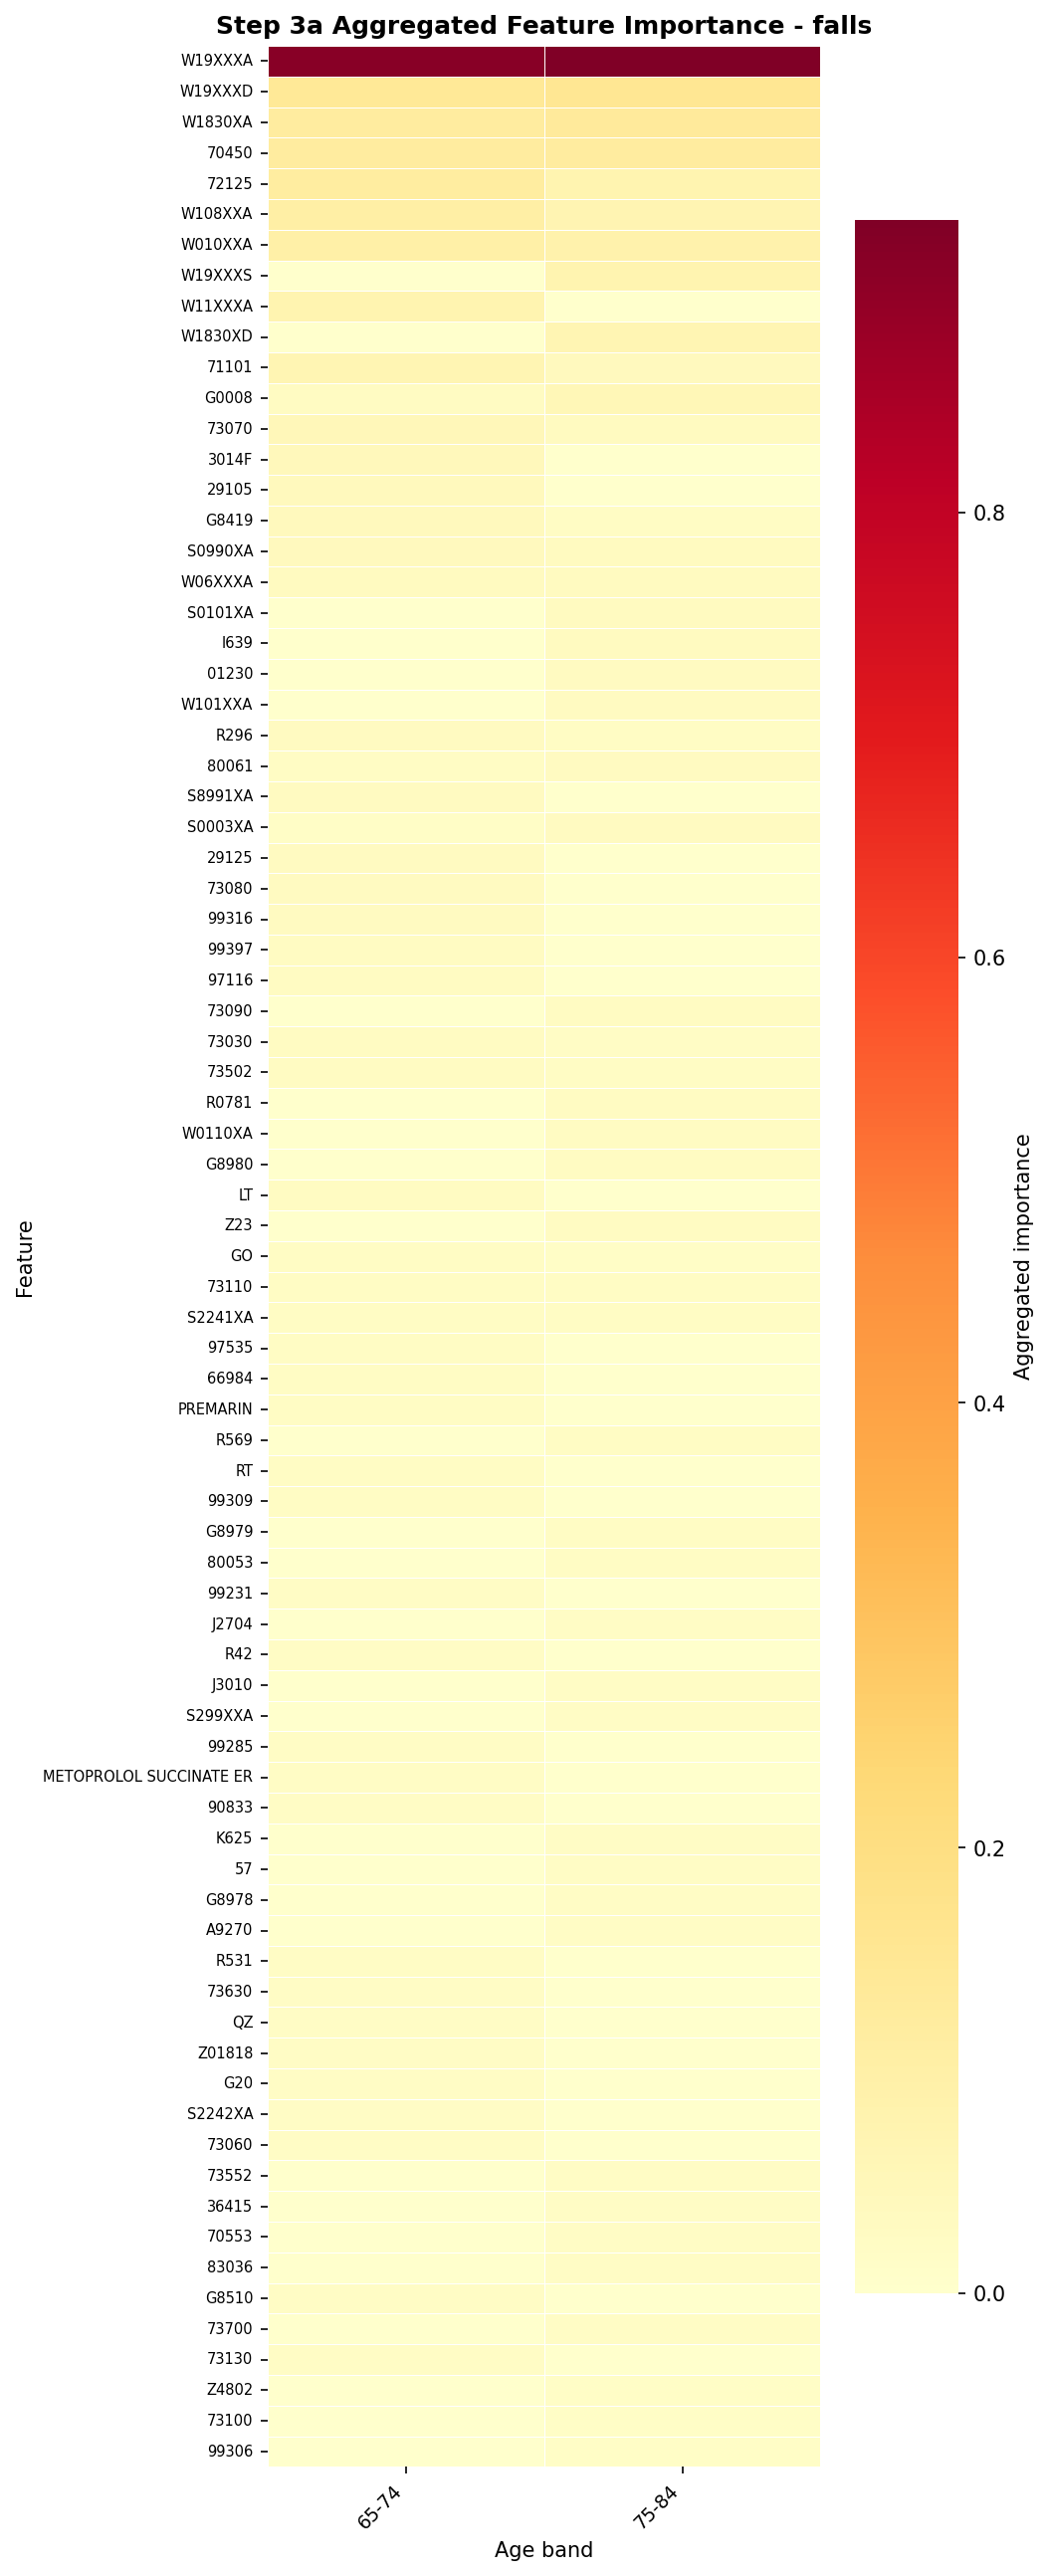

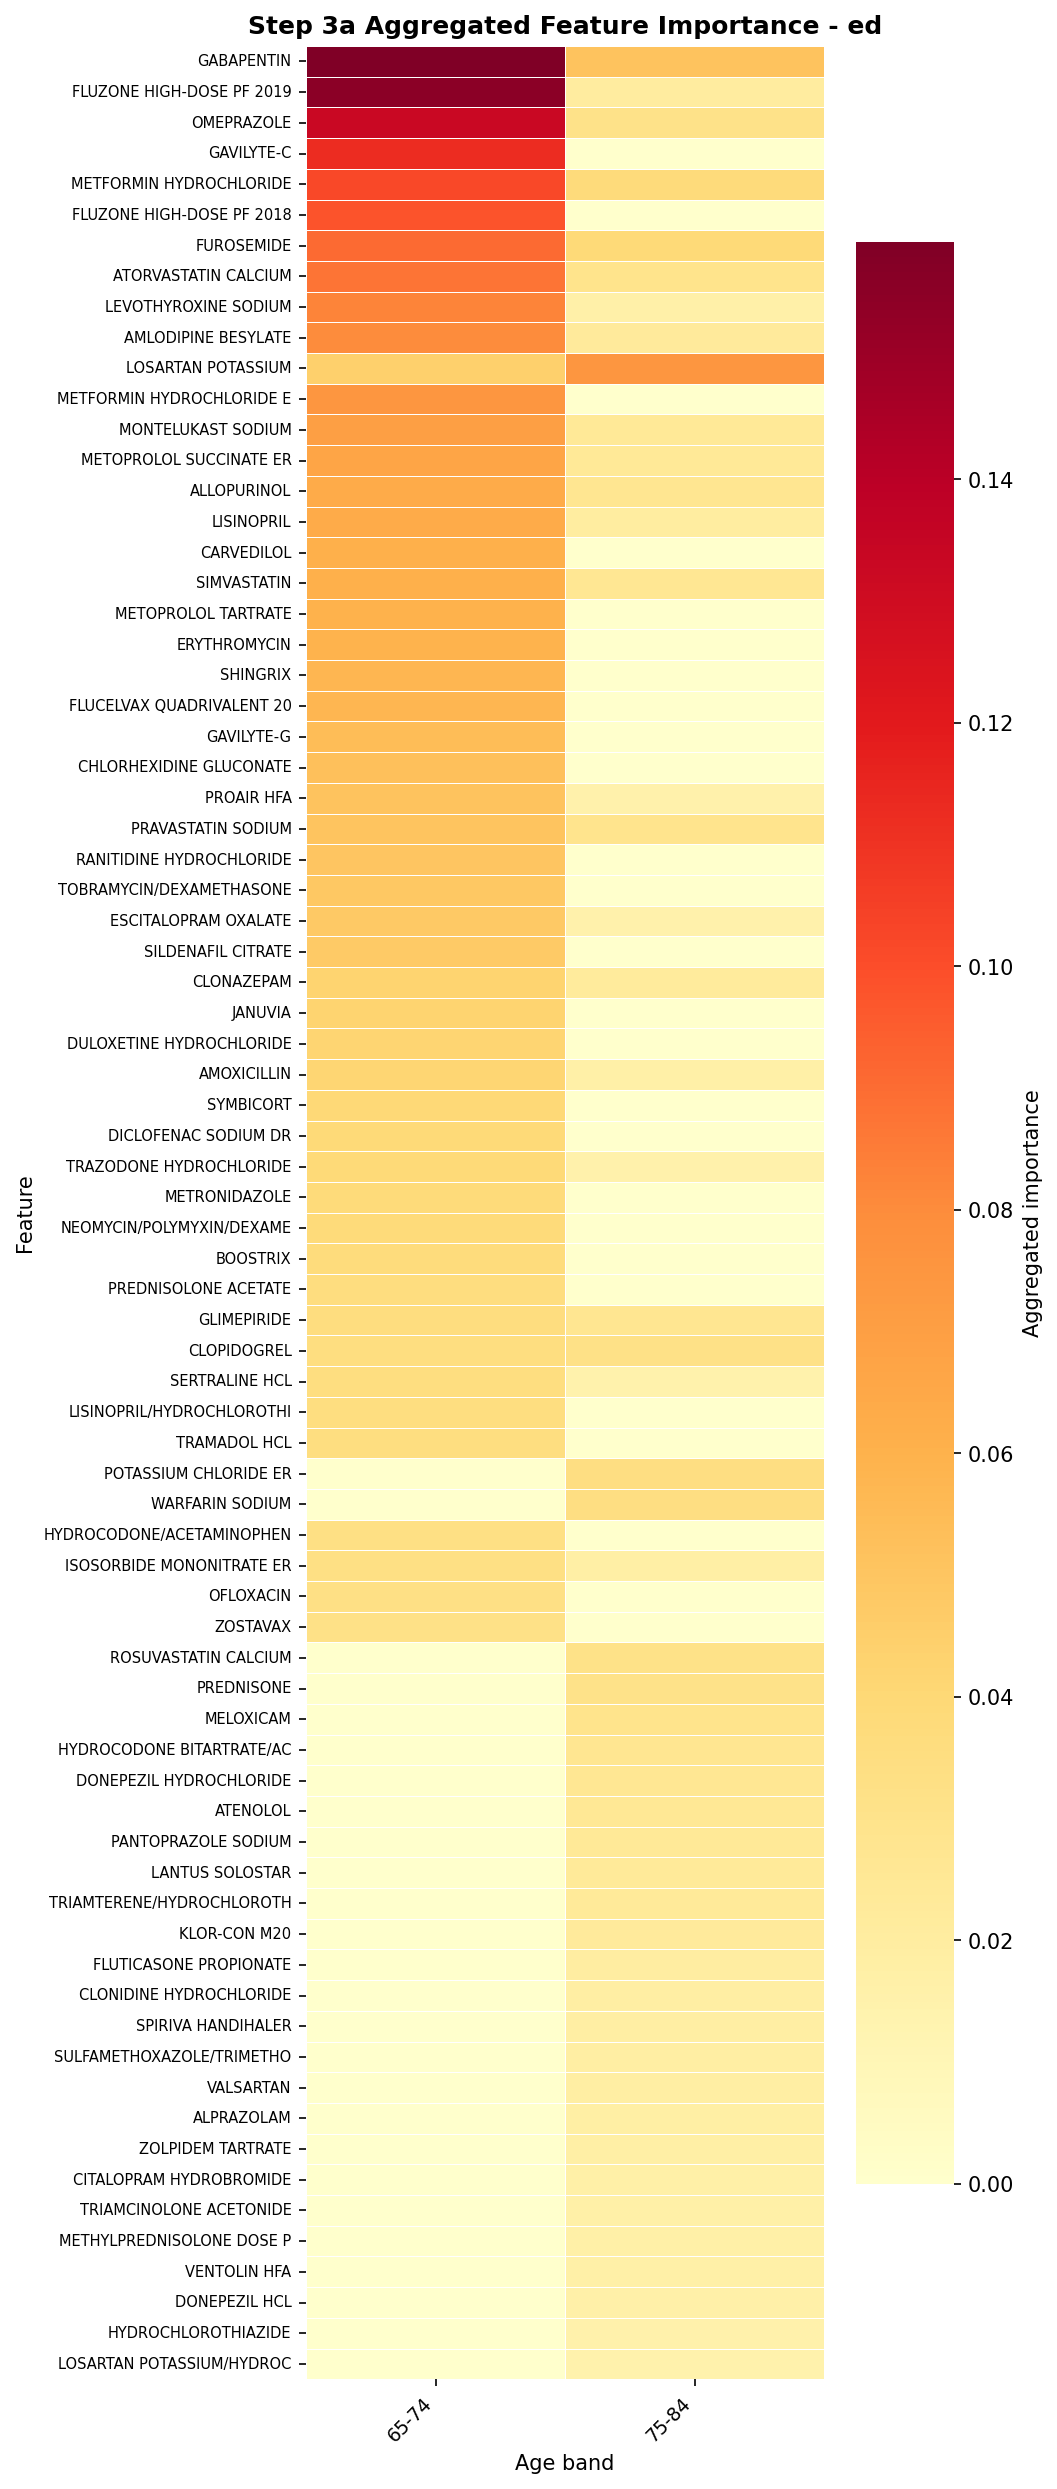

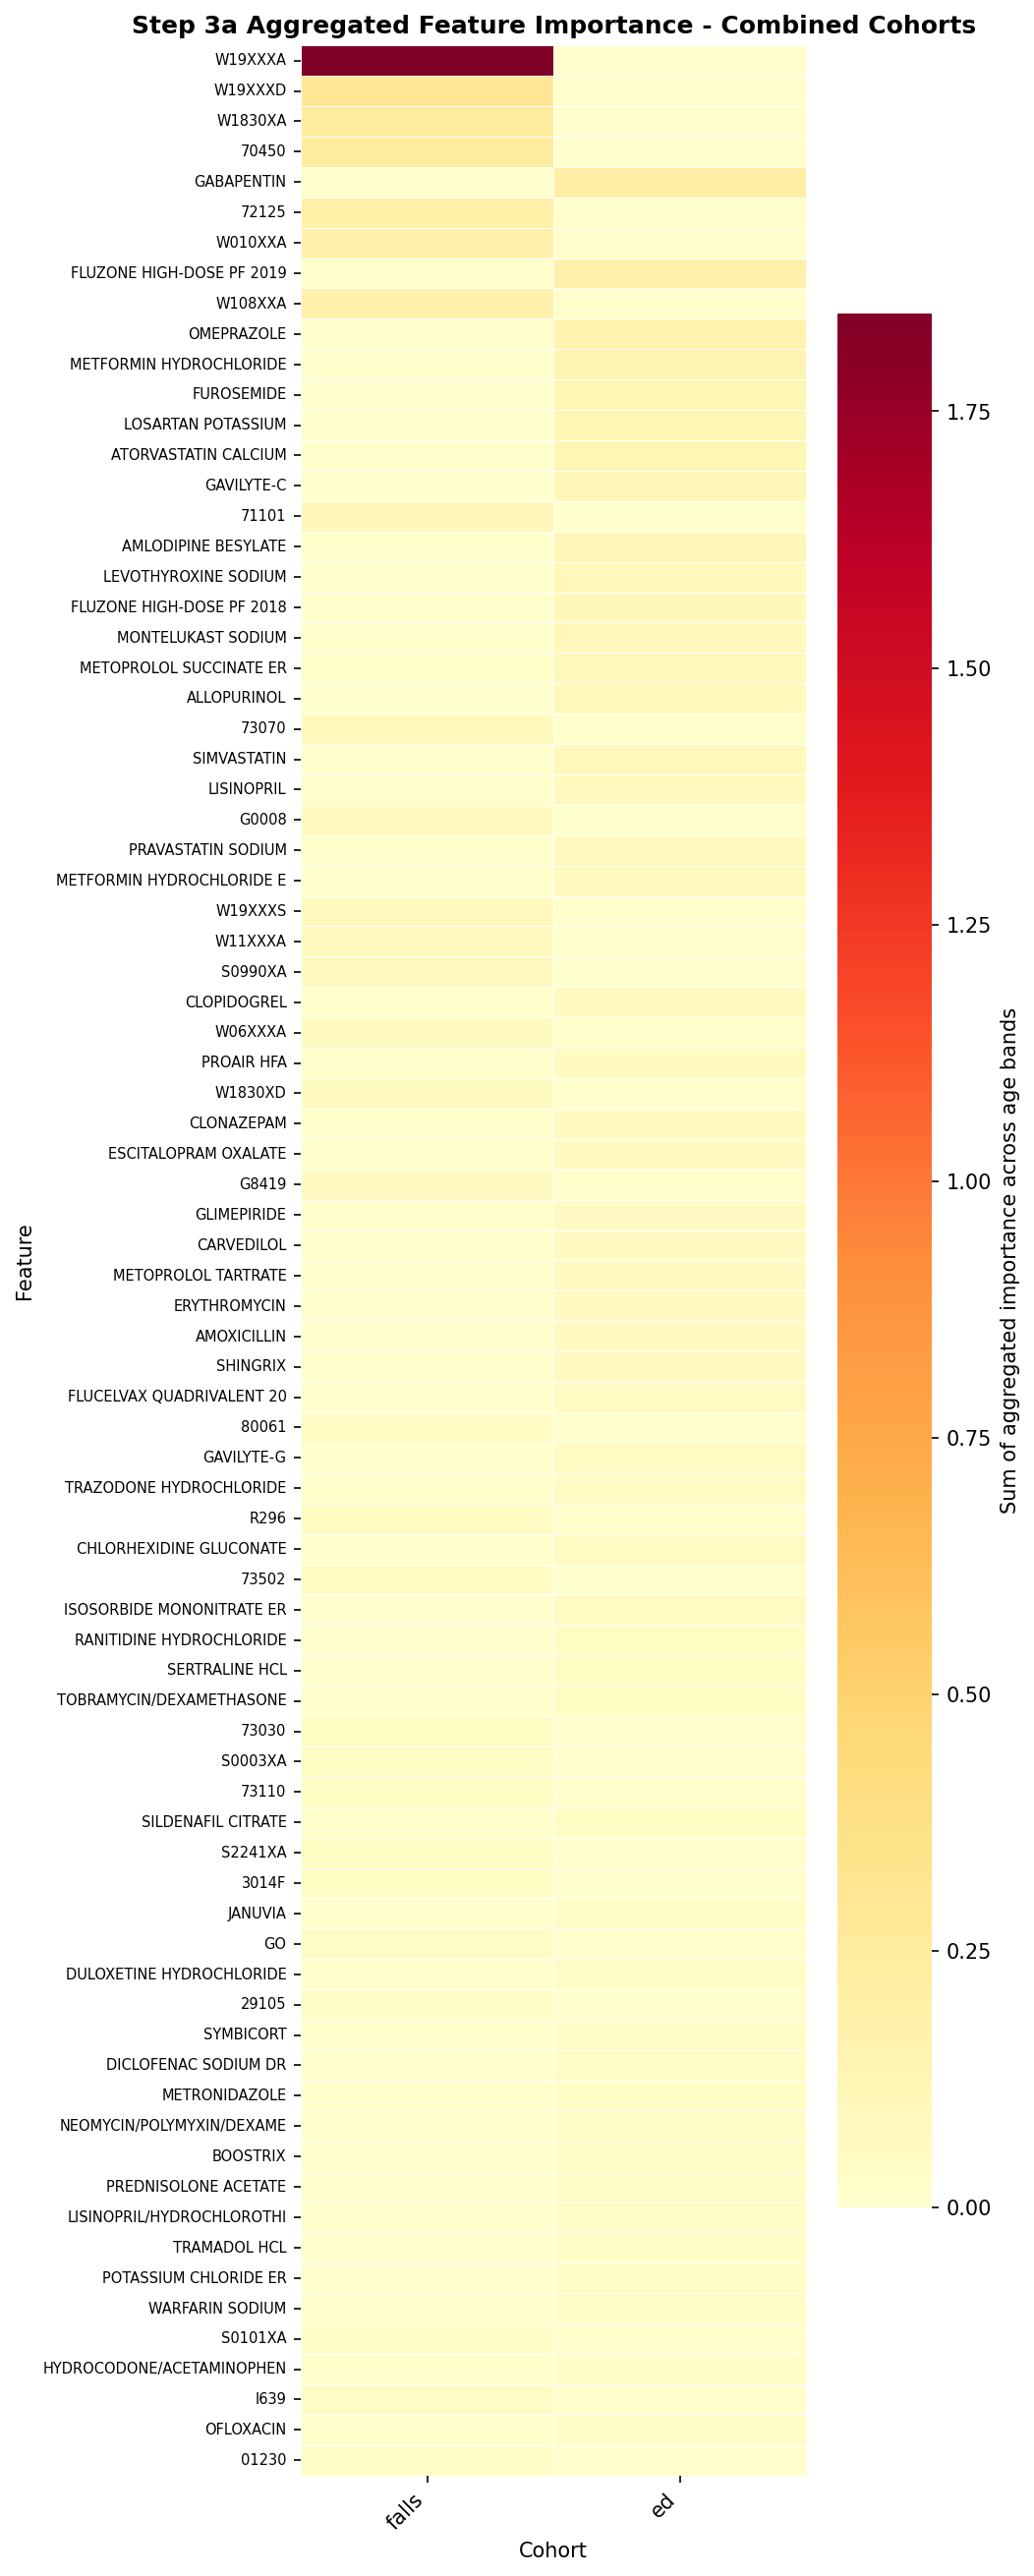

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

from py_helpers.env_utils import get_feature_importance_root

OUTPUTS_DIR = get_feature_importance_root()
AGE_BANDS = ["65-74", "75-84"]
TOP_N_PER_AGE_BAND = 50
COMBINED_TOP_N = 80
IMPORTANCE_COLUMNS = [
    "importance_scaled_by_model_sum",
    "scaled_importance_mean",
    "importance_mean",
    "importance_scaled",
    "importance_normalized",
    "importance",
]


def _resolve_step3a_aggregated_csv(cohort: str, age_band: str) -> Path | None:
    ab_f = age_band.replace("-", "_")
    filename = f"{cohort}_{ab_f}_aggregated_feature_importance.csv"
    candidates = [
        OUTPUTS_DIR / cohort / filename,
        OUTPUTS_DIR / cohort / ab_f / filename,
        OUTPUTS_DIR / cohort / age_band / filename,
    ]
    return next((path for path in candidates if path.exists()), None)


def _importance_column(df: pd.DataFrame) -> str | None:
    return next((col for col in IMPORTANCE_COLUMNS if col in df.columns), None)


def _display_feature_name(value: object) -> str:
    text = str(value)
    for prefix in ("item_drug_", "item_icd_", "item_cpt_", "item_"):
        if text.startswith(prefix):
            return text[len(prefix):]
    return text


def _load_step3a_fi(cohort: str, age_band: str) -> tuple[pd.DataFrame | None, Path | None, str | None]:
    csv_path = _resolve_step3a_aggregated_csv(cohort, age_band)
    if csv_path is None:
        return None, None, None
    df = pd.read_csv(csv_path)
    if "feature" not in df.columns:
        return None, csv_path, None
    importance_col = _importance_column(df)
    if importance_col is None:
        return None, csv_path, None
    df = df[["feature", importance_col]].copy()
    df[importance_col] = pd.to_numeric(df[importance_col], errors="coerce").fillna(0.0)
    df = df[df[importance_col] > 0]
    return df, csv_path, importance_col


def _build_cohort_heatmap(cohort: str) -> Path | None:
    frames = []
    source_paths = []
    importance_cols = []
    for age_band in AGE_BANDS:
        df, csv_path, importance_col = _load_step3a_fi(cohort, age_band)
        if df is None or csv_path is None or importance_col is None or df.empty:
            print(f"[WARN] Missing usable Step 3a FI for {cohort}/{age_band}")
            continue
        source_paths.append(csv_path)
        importance_cols.append(importance_col)
        top = df.nlargest(TOP_N_PER_AGE_BAND, importance_col).copy()
        top["age_band"] = age_band
        top = top.rename(columns={importance_col: "importance"})
        frames.append(top[["feature", "age_band", "importance"]])

    if len(frames) < 2:
        print(f"[WARN] Need at least two age bands for {cohort} heatmap; found {len(frames)}")
        return None

    combined = pd.concat(frames, ignore_index=True)
    pivot = combined.pivot_table(index="feature", columns="age_band", values="importance", aggfunc="max", fill_value=0.0)
    pivot["_max"] = pivot.max(axis=1)
    pivot = pivot.sort_values("_max", ascending=False).drop(columns="_max")
    pivot = pivot.head(max(TOP_N_PER_AGE_BAND, 80))
    pivot.index = [_display_feature_name(idx) for idx in pivot.index]

    plots_dir = OUTPUTS_DIR / cohort / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    out_path = plots_dir / f"{cohort}_step3a_aggregated_fi_heatmap.png"

    fig, ax = plt.subplots(figsize=(max(7, len(pivot.columns) * 2.4), max(10, len(pivot) * 0.22)))
    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        linewidths=0.4,
        cbar_kws={"label": "Aggregated importance"},
        ax=ax,
    )
    ax.set_title(f"Step 3a Aggregated Feature Importance - {cohort}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Age band")
    ax.set_ylabel("Feature")
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor="white", dpi=150)
    plt.close()
    print(f"[1] Saved {cohort} heatmap: {out_path}")
    print("    Sources:")
    for path in source_paths:
        print(f"    - {path}")
    return out_path


def _build_combined_heatmap() -> Path | None:
    cohort_feature_scores: dict[str, dict[str, float]] = {}
    for cohort in COHORTS:
        scores: dict[str, float] = {}
        for age_band in AGE_BANDS:
            df, csv_path, importance_col = _load_step3a_fi(cohort, age_band)
            if df is None or csv_path is None or importance_col is None or df.empty:
                continue
            top = df.nlargest(TOP_N_PER_AGE_BAND, importance_col)
            for _, row in top.iterrows():
                feature = str(row["feature"])
                scores[feature] = scores.get(feature, 0.0) + float(row[importance_col])
        if scores:
            cohort_feature_scores[cohort] = scores

    if not cohort_feature_scores:
        print("[WARN] No Step 3a FI data available for combined heatmap")
        return None

    all_features = sorted(
        {feature for scores in cohort_feature_scores.values() for feature in scores},
        key=lambda feature: -max(scores.get(feature, 0.0) for scores in cohort_feature_scores.values()),
    )[:COMBINED_TOP_N]
    pivot = pd.DataFrame(
        {cohort: [cohort_feature_scores[cohort].get(feature, 0.0) for feature in all_features] for cohort in cohort_feature_scores},
        index=[_display_feature_name(feature) for feature in all_features],
    )

    plots_dir = OUTPUTS_DIR / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    out_path = plots_dir / "combined_step3a_aggregated_fi_heatmap.png"

    fig, ax = plt.subplots(figsize=(max(7, len(pivot.columns) * 3), max(10, len(pivot) * 0.22)))
    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        linewidths=0.4,
        cbar_kws={"label": "Sum of aggregated importance across age bands"},
        ax=ax,
    )
    ax.set_title("Step 3a Aggregated Feature Importance - Combined Cohorts", fontsize=12, fontweight="bold")
    ax.set_xlabel("Cohort")
    ax.set_ylabel("Feature")
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", facecolor="white", dpi=150)
    plt.close()
    print(f"[1] Saved combined heatmap: {out_path}")
    return out_path


heatmaps = []
for cohort in COHORTS:
    path = _build_cohort_heatmap(cohort)
    if path is not None:
        heatmaps.append(path)
combined_path = _build_combined_heatmap()
if combined_path is not None:
    heatmaps.append(combined_path)

for path in heatmaps:
    display(Image(filename=str(path)))

# Build Step 3b target-leakage artifacts

Before final feature-importance rows can feed Step 4 model-data creation, build the Step 3b leakage artifacts for each active cohort and age band:

1. BupaR post-target analysis: `*_bupar_post_target_analysis.csv`
2. Safe feature filter: `*_safe_feature_filter.json`
3. Refined feature list: `*_cohort_feature_importance.csv`
4. Filtering summary: `*_feature_filtering_summary.json`

This step is idempotent at the notebook level: it skips cohort/age-band pairs that already have the required artifacts unless `FORCE_STEP3B_RERUN = True`. The next section consumes these files and writes the final auditable leakage-filtered outputs.

In [ ]:
import shutil
import subprocess
from pathlib import Path

import pandas as pd

from py_helpers.constants import age_band_to_fname
from py_helpers.env_utils import get_refined_feature_importance_root

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()
try:
    PYTHON_BIN
except NameError:
    import sys
    PYTHON_BIN = Path(sys.executable)

STEP3B_SCRIPT = PROJECT_ROOT / "3b_feature_importance_eda" / "run_feature_importance_eda.py"
REFINED_OUTPUTS_DIR = get_refined_feature_importance_root()
LEGACY_STEP3B_OUTPUTS_DIR = PROJECT_ROOT / "3b_feature_importance_eda" / "outputs"
AGE_BANDS = ["65-74", "75-84"]
FORCE_STEP3B_RERUN = False
STEP3B_FAIL_FAST = True


def _step3b_artifact_paths(cohort: str, age_band: str) -> dict[str, Path]:
    ab_f = age_band_to_fname(age_band)
    refined_dir = REFINED_OUTPUTS_DIR / cohort / ab_f
    legacy_dir = LEGACY_STEP3B_OUTPUTS_DIR / cohort / ab_f
    return {
        "refined_dir": refined_dir,
        "legacy_dir": legacy_dir,
        "safe_filter": refined_dir / f"{cohort}_{ab_f}_safe_feature_filter.json",
        "bupar_post_target": refined_dir / f"{cohort}_{ab_f}_bupar_post_target_analysis.csv",
        "legacy_bupar_post_target": legacy_dir / f"{cohort}_{ab_f}_bupar_post_target_analysis.csv",
        "cohort_fi": refined_dir / f"{cohort}_{ab_f}_cohort_feature_importance.csv",
        "filtering_summary": refined_dir / f"{cohort}_{ab_f}_feature_filtering_summary.json",
    }


def _copy_legacy_bupar_to_refined(paths: dict[str, Path]) -> None:
    src = paths["legacy_bupar_post_target"]
    dst = paths["bupar_post_target"]
    if src.exists() and not dst.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)
        print(f"[1] Copied BupaR post-target CSV to refined root: {dst}")


def _required_step3b_artifacts_exist(paths: dict[str, Path]) -> bool:
    _copy_legacy_bupar_to_refined(paths)
    required = ["safe_filter", "bupar_post_target", "cohort_fi", "filtering_summary"]
    return all(paths[name].exists() for name in required)


if not STEP3B_SCRIPT.exists():
    raise FileNotFoundError(f"Step 3b script not found: {STEP3B_SCRIPT}")

step3b_rows = []
for cohort in COHORTS:
    for age_band in COHORTS[cohort]:
        if age_band not in AGE_BANDS:
            continue

        paths = _step3b_artifact_paths(cohort, age_band)
        already_complete = _required_step3b_artifacts_exist(paths)
        if already_complete and not FORCE_STEP3B_RERUN:
            print(f"[1] Step 3b artifacts already present: {cohort}/{age_band}")
            exit_code = 0
            action = "skipped_existing"
        else:
            print(f"--> Step 3b leakage artifacts: {cohort} / {age_band}")
            result = subprocess.run(
                [str(PYTHON_BIN), str(STEP3B_SCRIPT), "--cohort", cohort, "--age-band", age_band],
                cwd=str(PROJECT_ROOT),
            )
            exit_code = result.returncode
            action = "ran"
            _copy_legacy_bupar_to_refined(paths)
            if exit_code != 0 and STEP3B_FAIL_FAST:
                raise RuntimeError(f"Step 3b failed for {cohort}/{age_band} with exit code {exit_code}")

        artifact_status = {name: paths[name].exists() for name in ["safe_filter", "bupar_post_target", "cohort_fi", "filtering_summary"]}
        print(f"  artifacts: {artifact_status}")
        if STEP3B_FAIL_FAST and not all(artifact_status.values()):
            missing = [name for name, exists in artifact_status.items() if not exists]
            raise FileNotFoundError(f"Missing Step 3b artifacts for {cohort}/{age_band}: {missing}")

        step3b_rows.append({
            "cohort": cohort,
            "age_band": age_band,
            "action": action,
            "exit_code": exit_code,
            **artifact_status,
        })

if step3b_rows:
    display(pd.DataFrame(step3b_rows))
else:
    print("No Step 3b cohort/age-band pairs selected.")

# Target leakage review and removal before model data

This section mirrors the robust PGx/Step 3b leakage workflow before Step 4 model-data creation. It is intentionally explicit so the leakage correction is visible in the feature-importance notebook rather than hidden downstream.

For each cohort and age band, the cell below:

1. Loads the Step 3a aggregated feature-importance CSV.
2. Loads optional Step 3b evidence if present: `safe_feature_filter.json`, `bupar_post_target_analysis.csv`, and `manual_filtering_config.json`.
3. Removes generic leakage patterns used by final model training (`post_*`, `time_to*`, target date/label fields, DTW, trajectory/sequence/itemset artifacts).
4. Removes cohort target-definition features. For falls, this includes the injury/external-cause ICD families used to build `fall_injury_any`, such as `W19XXXA`, `W00-W19`, `S*`, `T07`, and `T14`.
5. Applies the ED drug-only rule so ED model data does not ingest ICD/CPT target proxies.
6. Preserves an audit CSV explaining every removed feature and writes canonical `*_cohort_feature_importance.csv` files for Step 4 and Step 6.

Outputs are written to the refined feature-importance root and uploaded to `s3://{S3_BUCKET}/gold/{PROJECT_SLUG}/feature_importance/{cohort}/{age_band}/`.

In [ ]:
import json
import os
import shutil
import subprocess
from pathlib import Path

import pandas as pd

from py_helpers.constants import PROJECT_SLUG, S3_BUCKET, age_band_to_fname
from py_helpers.env_utils import get_feature_importance_root, get_refined_feature_importance_root
from py_helpers.feature_importance_filters import identify_fi_filter_reasons
from py_helpers.feature_utils import (
    code_to_canonical_feature_name,
    feature_to_code,
    feature_to_code_type,
    normalize_feature_name,
)

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

OUTPUTS_DIR = get_feature_importance_root()
REFINED_OUTPUTS_DIR = get_refined_feature_importance_root()
LEGACY_STEP3B_OUTPUTS_DIR = PROJECT_ROOT / "3b_feature_importance_eda" / "outputs"
AGE_BANDS = ["65-74", "75-84"]
POST_TARGET_RATIO_THRESHOLD = 0.80
MANUAL_CODES_TO_FILTER: list[str] = []
CODES_TO_KEEP: list[str] = []
_aws = shutil.which("aws") or "aws"
AWS_PROFILE = os.environ.get("AWS_PROFILE")
_profile = ["--profile", AWS_PROFILE] if AWS_PROFILE else []


def _resolve_step3a_aggregated_csv(cohort: str, age_band: str) -> Path | None:
    ab_f = age_band_to_fname(age_band)
    filename = f"{cohort}_{ab_f}_aggregated_feature_importance.csv"
    candidates = [
        OUTPUTS_DIR / cohort / filename,
        OUTPUTS_DIR / cohort / ab_f / filename,
        OUTPUTS_DIR / cohort / age_band / filename,
    ]
    return next((path for path in candidates if path.exists()), None)


def _artifact_dir(cohort: str, age_band: str) -> Path:
    return REFINED_OUTPUTS_DIR / cohort / age_band_to_fname(age_band)


def _artifact_dirs(cohort: str, age_band: str) -> list[Path]:
    ab_f = age_band_to_fname(age_band)
    dirs = [
        REFINED_OUTPUTS_DIR / cohort / ab_f,
        LEGACY_STEP3B_OUTPUTS_DIR / cohort / ab_f,
    ]
    out = []
    seen = set()
    for path in dirs:
        key = str(path.resolve()) if path.exists() else str(path)
        if key not in seen:
            seen.add(key)
            out.append(path)
    return out


def _first_existing_artifact(cohort: str, age_band: str, filename: str) -> Path | None:
    return next((path / filename for path in _artifact_dirs(cohort, age_band) if (path / filename).exists()), None)


def _read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(f"[WARN] Could not read JSON artifact {path}: {exc}")
        return {}


def _normal_feature_set(values: object) -> set[str]:
    if not values:
        return set()
    return {normalize_feature_name(str(value)) for value in values if str(value).strip()}


def _normal_code_set(values: object) -> set[str]:
    if not values:
        return set()
    return {str(value).strip().upper().replace(".", "") for value in values if str(value).strip()}


def _load_safe_feature_filter(cohort: str, age_band: str) -> tuple[set[str], set[str], Path | None]:
    ab_f = age_band_to_fname(age_band)
    filename = f"{cohort}_{ab_f}_safe_feature_filter.json"
    path = _first_existing_artifact(cohort, age_band, filename)
    if path is None:
        return set(), set(), None
    data = _read_json(path)
    if not data:
        return set(), set(), None
    keep = _normal_feature_set(data.get("all_features_to_keep", []))
    exclude = _normal_feature_set(data.get("all_features_to_exclude", []))
    return keep, exclude, path


def _load_manual_filter_config(cohort: str, age_band: str) -> tuple[set[str], set[str], Path | None]:
    ab_f = age_band_to_fname(age_band)
    filename = f"{cohort}_{ab_f}_manual_filtering_config.json"
    path = _first_existing_artifact(cohort, age_band, filename)
    data = _read_json(path) if path is not None else {}
    manual_filter = _normal_code_set(data.get("codes_to_filter", [])) | _normal_code_set(MANUAL_CODES_TO_FILTER)
    manual_keep = _normal_code_set(data.get("codes_to_keep", [])) | _normal_code_set(CODES_TO_KEEP)
    return manual_filter, manual_keep, path if data else None


def _load_bupar_post_target_features(cohort: str, age_band: str) -> tuple[set[str], Path | None]:
    ab_f = age_band_to_fname(age_band)
    filename = f"{cohort}_{ab_f}_bupar_post_target_analysis.csv"
    path = _first_existing_artifact(cohort, age_band, filename)
    if path is None:
        return set(), None

    df = pd.read_csv(path)
    if "feature" not in df.columns or df.empty:
        return set(), path

    flagged = pd.Series(False, index=df.index)
    if "is_post_target_leakage" in df.columns:
        vals = df["is_post_target_leakage"].astype(str).str.strip().str.lower()
        flagged = flagged | vals.isin({"1", "true", "yes"})
    for col in ("post_target_ratio", "post_f1120_ratio"):
        if col in df.columns:
            flagged = flagged | (pd.to_numeric(df[col], errors="coerce") >= POST_TARGET_RATIO_THRESHOLD).fillna(False)

    return _normal_feature_set(df.loc[flagged, "feature"].dropna().tolist()), path


def _canonical_feature_name(feature: object) -> str:
    raw_feature = str(feature)
    code_type = feature_to_code_type(raw_feature)
    raw_code = feature_to_code(raw_feature)
    canonical = code_to_canonical_feature_name(code_type, raw_code)
    return canonical if canonical else raw_feature


def _add_reason(audit: pd.DataFrame, mask: pd.Series, reason: str) -> None:
    if not bool(mask.any()):
        return
    current = audit.loc[mask, "reasons"].fillna("").astype(str)
    audit.loc[mask, "reasons"] = current.map(lambda value: f"{value};{reason}" if value else reason)
    audit.loc[mask, "remove"] = True


summaries = []
for cohort in COHORTS:
    for age_band in AGE_BANDS:
        source_csv = _resolve_step3a_aggregated_csv(cohort, age_band)
        if source_csv is None:
            print(f"[WARN] Missing Step 3a aggregated FI for {cohort}/{age_band}; skipping leakage filter")
            continue

        ab_f = age_band_to_fname(age_band)
        df = pd.read_csv(source_csv)
        if "feature" not in df.columns:
            print(f"[WARN] {source_csv} has no feature column; skipping")
            continue

        print("=" * 90)
        print(f"Target leakage review: {cohort} / {age_band}")
        print("=" * 90)
        original_count = len(df)
        audit = identify_fi_filter_reasons(df, PROJECT_ROOT, cohort=cohort, feature_col="feature")
        audit["feature_normalized"] = audit["feature"].map(normalize_feature_name)
        audit["raw_code_normalized"] = audit["raw_code"].astype(str).str.upper().str.replace(".", "", regex=False)

        safe_keep, safe_exclude, safe_path = _load_safe_feature_filter(cohort, age_band)
        bupar_post_target, bupar_path = _load_bupar_post_target_features(cohort, age_band)
        manual_filter, manual_keep, manual_path = _load_manual_filter_config(cohort, age_band)

        if safe_keep:
            _add_reason(
                audit,
                ~audit["feature_normalized"].isin(safe_keep),
                "safe_feature_filter_not_in_case_whitelist",
            )
        if safe_exclude:
            _add_reason(
                audit,
                audit["feature_normalized"].isin(safe_exclude),
                "safe_feature_filter_control_blacklist",
            )
        if bupar_post_target:
            _add_reason(
                audit,
                audit["feature_normalized"].isin(bupar_post_target),
                "bupar_post_target_ratio_ge_0_80",
            )
        if manual_filter:
            _add_reason(
                audit,
                audit["raw_code_normalized"].isin(manual_filter),
                "manual_code_review_filter",
            )
        if manual_keep:
            keep_mask = audit["raw_code_normalized"].isin(manual_keep)
            audit.loc[keep_mask, "remove"] = False
            audit.loc[keep_mask, "reasons"] = "manual_code_review_keep_override"

        reason_counts = (
            audit.loc[audit["remove"], "reasons"]
            .str.get_dummies(sep=";")
            .sum()
            .sort_values(ascending=False)
        )
        for reason, count in reason_counts.items():
            print(f"  - {reason}: {int(count)}")
        if reason_counts.empty:
            print("  - No leakage features identified by current rules/artifacts")

        filtered = df.loc[~audit["remove"].to_numpy()].copy()
        filtered["code_type"] = filtered["feature"].astype(str).map(feature_to_code_type)
        filtered["raw_code"] = filtered["feature"].astype(str).map(feature_to_code)
        filtered["feature"] = filtered["feature"].map(_canonical_feature_name)
        filtered = filtered.drop_duplicates(subset=["feature"], keep="first").reset_index(drop=True)

        out_dir = _artifact_dir(cohort, age_band)
        out_dir.mkdir(parents=True, exist_ok=True)
        out_csv = out_dir / f"{cohort}_{ab_f}_cohort_feature_importance.csv"
        audit_csv = out_dir / f"{cohort}_{ab_f}_target_leakage_filter_audit.csv"
        summary_path = out_dir / f"{cohort}_{ab_f}_feature_filtering_summary.json"
        filtered.to_csv(out_csv, index=False)
        audit.to_csv(audit_csv, index=False)

        summary = {
            "cohort": cohort,
            "age_band": age_band,
            "source_csv": str(source_csv),
            "output_csv": str(out_csv),
            "audit_csv": str(audit_csv),
            "original_features": int(original_count),
            "filtered_features": int(len(filtered)),
            "removed_features": int(audit["remove"].sum()),
            "post_target_ratio_threshold": POST_TARGET_RATIO_THRESHOLD,
            "safe_feature_filter_json": str(safe_path) if safe_path else None,
            "bupar_post_target_analysis_csv": str(bupar_path) if bupar_path else None,
            "manual_filtering_config_json": str(manual_path) if manual_path else None,
            "reason_counts": {str(k): int(v) for k, v in reason_counts.items()},
            "removed_feature_sample": audit.loc[audit["remove"], ["feature", "reasons"]].head(50).to_dict("records"),
        }
        summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
        summaries.append(summary)

        s3_prefix = f"s3://{S3_BUCKET}/gold/{PROJECT_SLUG}/feature_importance/{cohort}/{age_band}/"
        for local_path in (out_csv, audit_csv, summary_path):
            result = subprocess.run(
                [_aws, "s3", "cp", str(local_path), f"{s3_prefix}{local_path.name}"] + _profile,
                capture_output=True,
                text=True,
            )
            if result.returncode == 0:
                print(f"[1] Uploaded {local_path.name} to {s3_prefix}")
            else:
                print(f"[X] Upload failed for {local_path}: {result.stderr or result.stdout}")
                raise RuntimeError(f"S3 upload failed for {local_path}")

        print(
            f"[1] {cohort}/{age_band}: {original_count} -> {len(filtered)} features "
            f"({int(audit['remove'].sum())} removed). Canonical output: {out_csv}"
        )

if summaries:
    display(pd.DataFrame(summaries)[[
        "cohort",
        "age_band",
        "original_features",
        "filtered_features",
        "removed_features",
        "safe_feature_filter_json",
        "bupar_post_target_analysis_csv",
    ]])
else:
    print("No leakage-filtered feature-importance files were written.")

# Sync Results and Code to S3

Sync Step 3a output files to the project-scoped S3 prefix only:

`s3://{S3_BUCKET}/gold/{PROJECT_SLUG}/feature_importance/`

In [13]:
import os
import shutil
import subprocess

from py_helpers.env_utils import get_feature_importance_root

# Sync 3a outputs to the project-scoped S3 prefix (idempotent).
S3_BUCKET = os.environ.get("CPIC_S3_BUCKET", "pgxdatalake")
PROJECT_SLUG = os.environ.get("CPIC_PROJECT_SLUG", "cpic_time_to_event")
S3_FI_PREFIX = f"s3://{S3_BUCKET}/gold/{PROJECT_SLUG}/feature_importance/"
OUTPUTS_DIR = get_feature_importance_root()
_aws = shutil.which("aws") or "aws"
AWS_PROFILE = os.environ.get("AWS_PROFILE")
_profile = ["--profile", AWS_PROFILE] if AWS_PROFILE else []

if OUTPUTS_DIR.exists():
    print(f"Syncing Step 3a outputs from: {OUTPUTS_DIR}")
    print(f"Syncing Step 3a outputs to:   {S3_FI_PREFIX}")
    r = subprocess.run(
        [_aws, "s3", "sync", str(OUTPUTS_DIR), S3_FI_PREFIX] + _profile,
        capture_output=False,
    )
    print(f"S3 sync exit code: {r.returncode}")
else:
    print(f"Outputs dir not found: {OUTPUTS_DIR}")

Syncing Step 3a outputs from: /mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs
Syncing Step 3a outputs to:   s3://pgxdatalake/gold/cpic_time_to_event/feature_importance/
upload: ../../../mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/_baseline/ed_65_74_aggregated_feature_importance.csv to s3://pgxdatalake/gold/cpic_time_to_event/feature_importance/ed/_baseline/ed_65_74_aggregated_feature_importance.csv
upload: ../../../mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/_baseline/ed_65_74_catboost_feature_importance_mc25.csv to s3://pgxdatalake/gold/cpic_time_to_event/feature_importance/ed/_baseline/ed_65_74_catboost_feature_importance_mc25.csv
upload: ../../../mnt/nvme/cpic_time_to_event/3a_feature_importance/outputs/ed/_baseline/ed_65_74_xgboost_rf_feature_importance_mc25.csv to s3://pgxdatalake/gold/cpic_time_to_event/feature_importance/ed/_baseline/ed_65_74_xgboost_rf_feature_importance_mc25.csv
upload: ../../../mnt/nvme/cpic_time_to_event/3a_featur

# Shutdown EC2

In [ ]:
import shutil, subprocess as _sp, os

SHUTDOWN_EC2 = False  # Set True when running on EC2

if SHUTDOWN_EC2:
    try:
        instance_id = _sp.run(
            ["curl", "-s", "http://169.254.169.254/latest/meta-data/instance-id"],
            capture_output=True, text=True, timeout=5
        ).stdout.strip()
        if instance_id:
            aws_cmd = shutil.which("aws") or "aws"
            _profile = ["--profile", os.environ["AWS_PROFILE"]] if os.environ.get("AWS_PROFILE") else []
            r = _sp.run([aws_cmd, "ec2", "stop-instances", "--instance-ids", instance_id] + _profile,
                        capture_output=True, text=True)
            print(f"EC2 stop {instance_id}: {'OK' if r.returncode == 0 else r.stderr.strip()}")
        else:
            print("EC2 instance ID not found - are you on EC2?")
    except Exception as e:
        print(f"EC2 shutdown skipped: {e}")
else:
    print("EC2 auto-shutdown DISABLED (SHUTDOWN_EC2 = False)")